# Guided Numeric Exploration — AI & Data Science Job Salaries 2026
_Pay, remote work, AI-tool use, and automation fear in a synthetic 5,000-role panel_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [uditjain13/ai-and-data-science-job-salaries-2026](https://www.kaggle.com/datasets/uditjain13/ai-and-data-science-job-salaries-2026)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Salary & Roles](#Univariate)** <br>
**4. [Experience, Remote, Geography](#Structure)** <br>
**5. [AI Tools, Satisfaction, Automation Fear](#AITools)** <br>
**6. [Multivariate Association](#Association)** <br>
**7. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
This is a **synthetic** 5,000×27 table of AI/data roles built for modeling practice (CC0). Beyond classic salary fields it includes daily AI-tool use, AI hours, certifications, equity/bonus, satisfaction, and a self-reported `fears_ai_automation_score`.

I treat associations as properties of the generator, not real employer pay bands. When sketching salary predictors I exclude equity/bonus as leakage-adjacent compensation components.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances, PCA), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "ai_ds_job_salaries_2026.csv"
KAGGLE_SLUG = "uditjain13/ai-and-data-science-job-salaries-2026"
EXPECTED_COLS = [
    "job_title", "experience_level", "employment_type", "company_size", "company_location",
    "employee_residence", "industry", "remote_ratio", "years_experience", "education_level",
    "primary_language", "has_ml_in_title", "manages_people", "team_size", "certifications_count",
    "weekly_hours", "uses_ai_tools_daily", "ai_tools_hours_per_week", "salary_currency", "salary_usd",
    "equity_offered_pct", "bonus_pct", "job_satisfaction_score", "interviews_to_offer",
    "switched_jobs_last_year", "upskilling_hours_per_month", "fears_ai_automation_score",
]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(CSV_BASENAME):
            return p
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / CSV_BASENAME
    if not p.exists():
        hits = list(root.rglob(CSV_BASENAME))
        assert hits, f"expected {CSV_BASENAME} under {root}"
        p = hits[0]
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)
df = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert len(df) == 5000, f"expected 5000 rows, got {len(df)}"
assert df.isnull().sum().sum() == 0, "card claims zero nulls"
assert (df["salary_usd"] > 0).all()

unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
print("Missing Values:", df.isnull().sum().sum())
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("salary_usd mean/median:", round(df["salary_usd"].mean()), round(df["salary_usd"].median()))


  0%|          | 0.00/164k [00:00<?, ?B/s]

100%|██████████| 164k/164k [00:00<00:00, 596kB/s]

100%|██████████| 164k/164k [00:00<00:00, 594kB/s]

Extracting files...


CSV: /Users/nicapotato/.cache/kagglehub/datasets/uditjain13/ai-and-data-science-job-salaries-2026/versions/4/ai_ds_job_salaries_2026.csv
Missing Values: 0
Dataframe Dimension: 5000 Rows, 27 Columns
salary_usd mean/median: 98605 90572


**Code Explanation and Reasoning:** <br>
Schema and the zero-null claim are asserted. This is synthetic practice data — useful for pattern discovery and modeling drills, not for quoting real 2026 offers.


In [3]:
df.sample(5, random_state=7)


,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,primary_language,has_ml_in_title,manages_people,team_size,certifications_count,weekly_hours,uses_ai_tools_daily,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
3406,Research Scientist,Senior,Full-time,M,AU,AU,Retail,100,11.3,Masters,SQL,True,False,4,2,39.1,True,11.7,AUD,150998,0.075,3.4,7.2,5,False,6.6,3.0
757,LLM Engineer,Mid,Freelance,M,IN,IN,Technology,50,8.7,Bootcamp,SQL,True,False,10,2,45.1,True,7.5,INR,31528,0.200,15.1,5.8,5,True,14.2,4.1
3624,MLOps Engineer,Entry,Contract,M,US,US,Energy,100,1.7,Masters,Python,False,False,10,5,40.0,True,10.0,USD,68910,0.125,2.1,7.0,5,False,12.7,7.7
4544,Data Scientist,Senior,Full-time,L,US,US,Technology,50,10.4,Bachelors,Python,False,False,7,0,46.7,True,13.0,USD,176945,0.000,9.3,6.4,5,False,1.0,1.0
3235,Business Intelligence Analyst,Senior,Full-time,M,US,US,Education,100,11.7,PhD,Python,False,True,5,1,39.2,True,9.9,USD,116251,0.029,12.1,7.8,6,False,6.8,7.7


In [4]:
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]).sort_values("Unique", ascending=False).head(20))
df[["salary_usd", "years_experience", "ai_tools_hours_per_week", "fears_ai_automation_score", "job_satisfaction_score"]].describe().T.round(2)


,Column,Unique,Null
19,salary_usd,4928,0
20,equity_offered_pct,684,0
15,weekly_hours,344,0
21,bonus_pct,258,0
17,ai_tools_hours_per_week,240,0
8,years_experience,230,0
25,upskilling_hours_per_month,217,0
26,fears_ai_automation_score,91,0
22,job_satisfaction_score,80,0
13,team_size,19,0


,count,mean,std,min,25%,50%,75%,max
salary_usd,5000.0,98605.41,55369.31,12000.0,55592.75,90572.0,129657.75,372347.0
years_experience,5000.0,8.36,4.82,0.0,4.80,8.1,11.50,23.7
ai_tools_hours_per_week,5000.0,8.44,5.50,0.0,3.30,8.5,12.62,25.2
fears_ai_automation_score,5000.0,4.85,1.73,1.0,3.70,4.8,6.00,10.0
job_satisfaction_score,5000.0,6.69,1.36,1.1,5.80,6.7,7.60,10.0


**Interpretation** <br>
Salary is continuous and right-skewed. Experience level, title, location, and remote ratio are the usual structural axes; AI-tool and fear scores are the distinctive 2026-era fields.


# **3. Univariate Salary & Roles:** <a id="Univariate"></a>


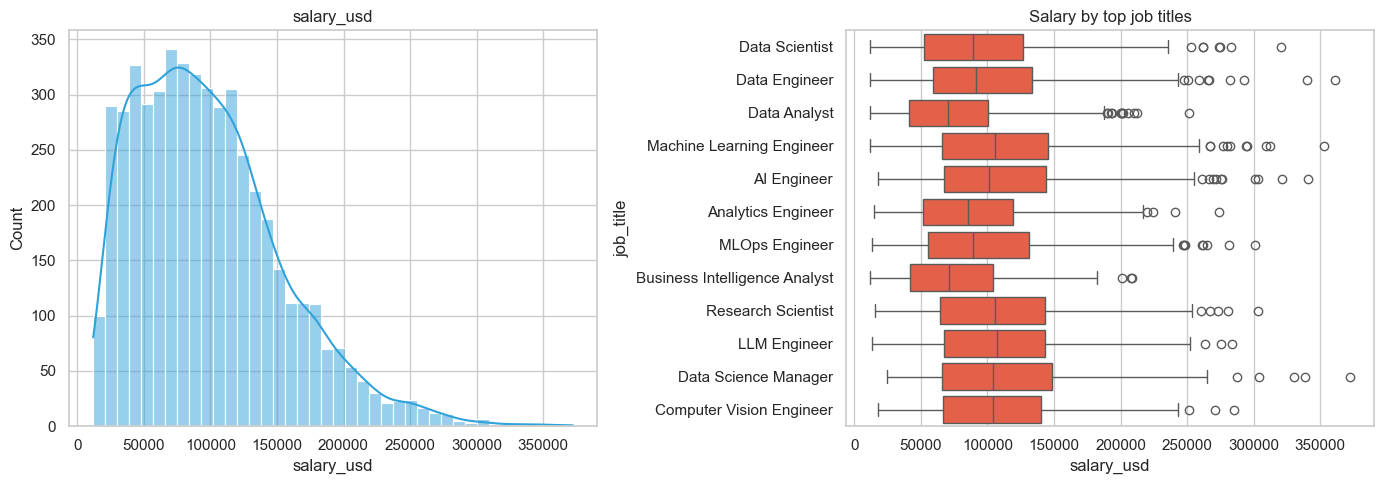

,n
job_title,
Data Scientist,709
Data Engineer,682
Data Analyst,627
Machine Learning Engineer,593
AI Engineer,506
Analytics Engineer,317
MLOps Engineer,306
Business Intelligence Analyst,293
Research Scientist,269


In [5]:
f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["salary_usd"], bins=40, kde=True, ax=ax[0], color="#30a2da")
ax[0].set_title("salary_usd")
top_titles = df["job_title"].value_counts().head(12).index
sns.boxplot(
    data=df[df["job_title"].isin(top_titles)],
    y="job_title", x="salary_usd", order=top_titles, ax=ax[1], color="#fc4f30",
)
ax[1].set_title("Salary by top job titles")
plt.tight_layout()
plt.show()
display(df["job_title"].value_counts().head(12).to_frame("n"))


**How to Interpret:** <br>
Title boxes show which role labels the generator pays up. Overlap across titles means title alone is a noisy salary signal once seniority and market enter.


# **4. Experience, Remote, Geography:** <a id="Structure"></a>


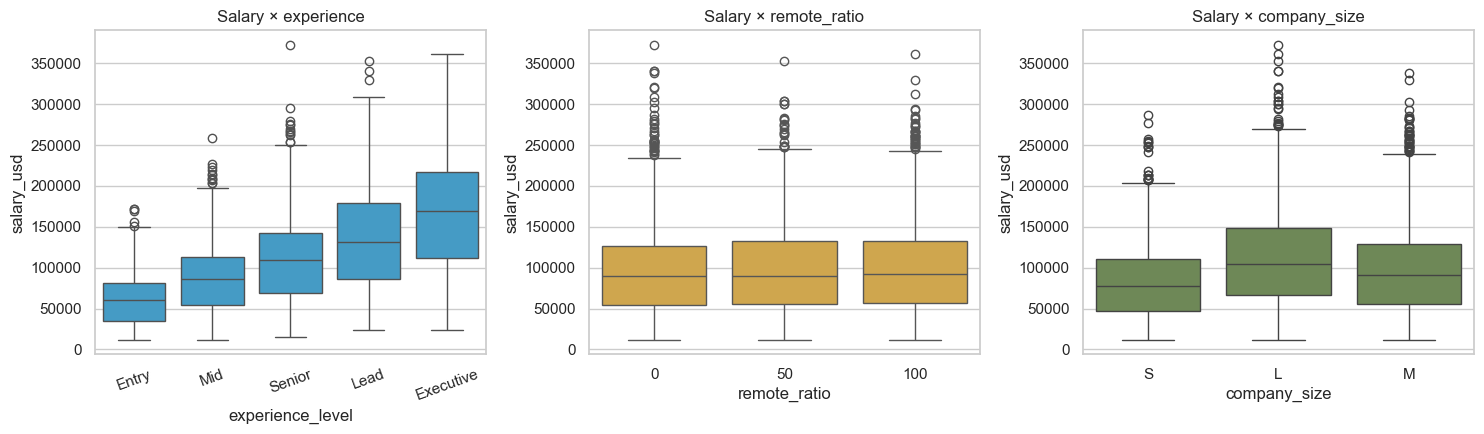

,mean,median,count
company_location,,,
US,135662.0,126987.0,1786
CA,107261.0,101216.0,350
AU,108565.0,100133.0,240
GB,100562.0,95321.0,488
NL,102304.0,94470.0,200
DE,96419.0,89107.0,350
FR,85178.0,78405.0,189
PL,58489.0,56120.0,147
BR,38230.0,36069.0,210


In [6]:
exp_order = ["Entry", "Mid", "Senior", "Lead", "Executive"]
exp_order = [e for e in exp_order if e in set(df["experience_level"])]
f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=df, x="experience_level", y="salary_usd", order=exp_order, ax=ax[0], color="#30a2da")
ax[0].set_title("Salary × experience")
ax[0].tick_params(axis="x", rotation=20)
sns.boxplot(data=df, x="remote_ratio", y="salary_usd", ax=ax[1], color="#e5ae38")
ax[1].set_title("Salary × remote_ratio")
sns.boxplot(data=df, x="company_size", y="salary_usd", ax=ax[2], color="#6d904f")
ax[2].set_title("Salary × company_size")
plt.tight_layout()
plt.show()

top_loc = df["company_location"].value_counts().head(10).index
loc_pay = (
    df[df["company_location"].isin(top_loc)]
    .groupby("company_location")["salary_usd"]
    .agg(["mean", "median", "count"])
    .sort_values("median", ascending=False)
    .round(0)
)
display(loc_pay)


**How to Interpret:** <br>
Experience should dominate if the generator is well-behaved. Remote ratio premium/discount and company-size gaps are the next structural questions; location medians need count context (small n cells are noisy).


# **5. AI Tools, Satisfaction, Automation Fear:** <a id="AITools"></a>


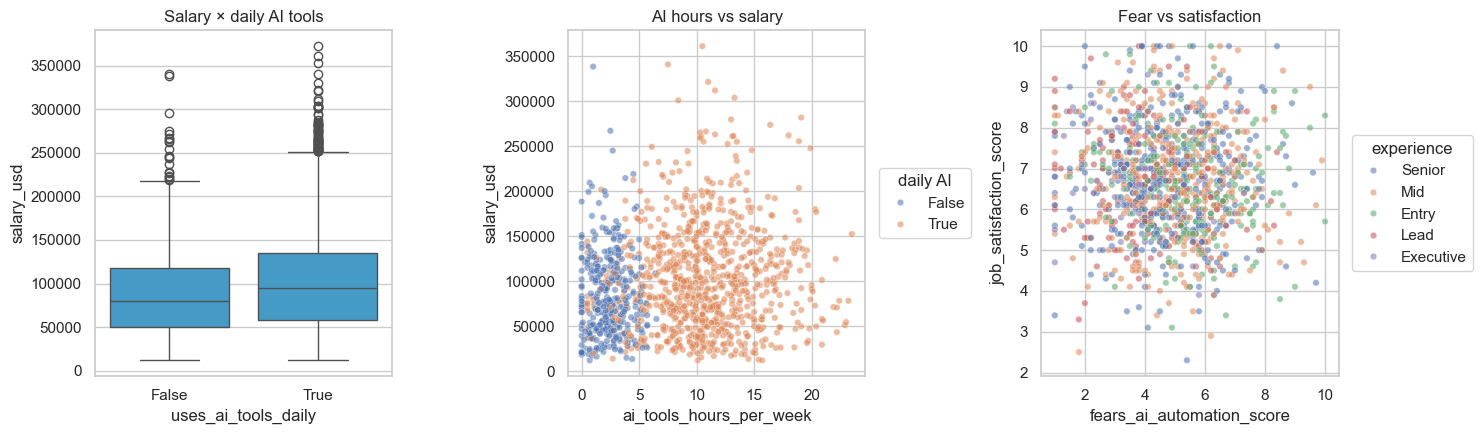

experience_level,Entry,Mid,Senior,Lead,Executive
title_family,,,,,
AI/ML-family,68104.0,94386.0,122637.0,147028.0,199252.0
Other DS/Analytics,53900.0,79792.0,101715.0,123762.0,154542.0


In [7]:
f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=df, x="uses_ai_tools_daily", y="salary_usd", ax=ax[0], color="#30a2da")
ax[0].set_title("Salary × daily AI tools")
sns.scatterplot(
    data=df.sample(1200, random_state=7),
    x="ai_tools_hours_per_week", y="salary_usd",
    hue="uses_ai_tools_daily", ax=ax[1], alpha=0.55, s=22,
)
ax[1].set_title("AI hours vs salary")
ax[1].legend(title="daily AI", bbox_to_anchor=(1.02, 0.5), loc="center left")
sns.scatterplot(
    data=df.sample(1200, random_state=7),
    x="fears_ai_automation_score", y="job_satisfaction_score",
    hue="experience_level", ax=ax[2], alpha=0.55, s=22,
)
ax[2].set_title("Fear vs satisfaction")
ax[2].legend(title="experience", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()

# Title family: AI/LLM vs classic DS
df["title_family"] = np.where(
    df["job_title"].str.contains("AI|LLM|MLOps|Machine Learning|Computer Vision", case=False, regex=True),
    "AI/ML-family",
    "Other DS/Analytics",
)
display(
    df.groupby(["title_family", "experience_level"])["salary_usd"]
    .median()
    .unstack()
    .reindex(columns=exp_order)
    .round(0)
)


**How to Interpret:** <br>
Daily AI-tool use vs pay asks whether tooling tracks a premium in this synthetic world. Fear vs satisfaction stratified by seniority shows who the generator paints as anxious. Title-family medians by experience partially control seniority when comparing AI/ML labels to classic roles.


# **6. Multivariate Association:** <a id="Association"></a>


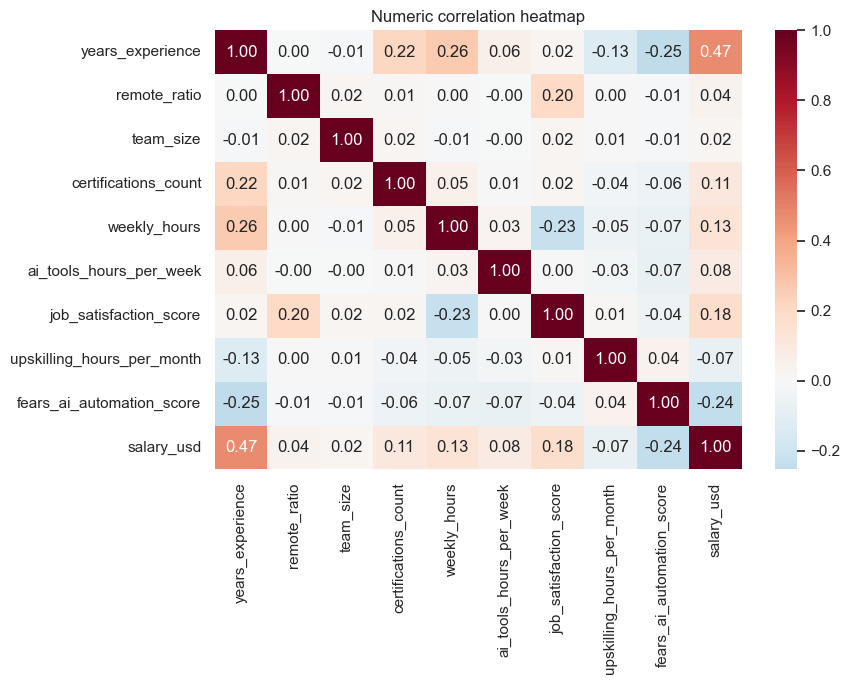

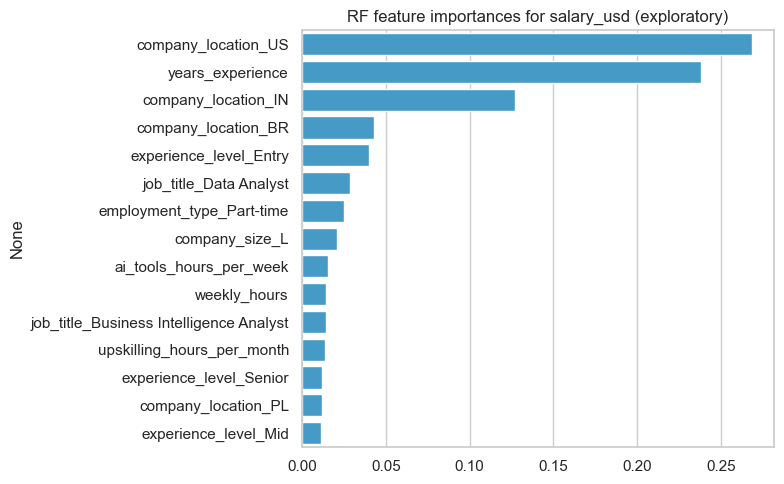

RF in-sample R^2: 0.908


In [8]:
num_cols = [
    "years_experience", "remote_ratio", "team_size", "certifications_count", "weekly_hours",
    "ai_tools_hours_per_week", "job_satisfaction_score", "upskilling_hours_per_month",
    "fears_ai_automation_score", "salary_usd",
]
corr = df[num_cols].corr()
f, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Numeric correlation heatmap")
plt.tight_layout()
plt.show()

# Light RF importances for salary — exclude equity/bonus (compensation leakage)
feature_num = [
    "years_experience", "remote_ratio", "team_size", "certifications_count", "weekly_hours",
    "ai_tools_hours_per_week", "upskilling_hours_per_month", "interviews_to_offer",
]
feature_cat = [
    "experience_level", "job_title", "company_size", "company_location",
    "education_level", "industry", "uses_ai_tools_daily", "employment_type",
]
X = df[feature_num + feature_cat]
y = df["salary_usd"]
pre = ColumnTransformer(
    [
        ("num", "passthrough", feature_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cat),
    ]
)
pipe = Pipeline([
    ("pre", pre),
    ("rf", RandomForestRegressor(n_estimators=200, random_state=7, n_jobs=-1, max_depth=12)),
])
pipe.fit(X, y)
# importances on transformed space are awkward; use permutation-free RF on encoded matrix
enc = pipe.named_steps["pre"]
rf = pipe.named_steps["rf"]
names = feature_num + list(enc.named_transformers_["cat"].get_feature_names_out(feature_cat))
imp = pd.Series(rf.feature_importances_, index=names).sort_values(ascending=False).head(15)
f, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, ax=ax, color="#30a2da")
ax.set_title("RF feature importances for salary_usd (exploratory)")
plt.tight_layout()
plt.show()
print("RF in-sample R^2:", round(rf.score(enc.transform(X), y), 3))


**How to Interpret:** <br>
Correlations are linear association snapshots. RF importances are exploratory and in-sample — they rank what the tree ensemble used, not causal drivers. Equity/bonus were excluded so the model is not rewarded for predicting pay with other pay pieces.


# **7. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A synthetic 2026 AI/DS salary panel with tooling and automation-fear fields built for learning.

**Working takeaways:** <br>
- Seniority and market structure dominate salary; title gaps need experience controls.
- AI-tool usage / fear / satisfaction are available for secondary stories beyond pay.
- Quote nothing here as a real offer band.

**Open follow-ups:** <br>
- Partial dependence of remote_ratio after experience + location.
- Who fears automation most after controlling for title family?
